<h1 align="center"><b>Dhvani Shah</b><br><b>Loan Default Predictor</b></h1>
<h3 align="center"><b>Advanced Classification Pipeline: Model Evaluation, Overfitting Checks, 5-Fold Cross-Validation & Hyperparameter Tuning (Random Forest)</b></h3>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)


In [2]:
df = pd.read_csv('Loan_default.csv.zip')
df = df.set_index('LoanID')
print(f'Dataset Shape: {df.shape[0]:,} rows, {df.shape[1]} columns')
df.head()

Dataset Shape: 255,347 rows, 17 columns


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
LoanID,,,,,,,,,,,,,,,,,
I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [3]:
x = df.drop(columns='Default')
y = df['Default']


print(x.head())

print(y.value_counts(normalize=True).map(lambda p: f'{p:.2%}'))

            Age  Income  LoanAmount  CreditScore  MonthsEmployed  \
LoanID                                                             
I38PQUQS96   56   85994       50587          520              80   
HPSK72WA7R   69   50432      124440          458              15   
C1OZ6DPJ8Y   46   84208      129188          451              26   
V2KKSFM3UN   32   31713       44799          743               0   
EY08JDHTZP   60   20437        9139          633               8   

            NumCreditLines  InterestRate  LoanTerm  DTIRatio    Education  \
LoanID                                                                      
I38PQUQS96               4         15.23        36      0.44   Bachelor's   
HPSK72WA7R               1          4.81        60      0.68     Master's   
C1OZ6DPJ8Y               3         21.17        24      0.31     Master's   
V2KKSFM3UN               3          7.07        24      0.23  High School   
EY08JDHTZP               4          6.51        48      0.73 

In [4]:

x_encoded = pd.get_dummies(x, drop_first=True)


numerical_columns = [
    'Age', 'Income', 'LoanAmount', 'CreditScore', 
    'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'DTIRatio', 'LoanTerm'
]

Normalized_x = x_encoded.copy()
scaler = MinMaxScaler()
Normalized_x[numerical_columns] = scaler.fit_transform(x_encoded[numerical_columns])


joblib.dump(scaler, 'scaler.pkl')
print('✓ Scaler successfully fitted and saved to scaler.pkl')


X_train, X_test, y_train, y_test = train_test_split(
    Normalized_x, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training Set: {X_train.shape[0]:,} samples, {X_train.shape[1]} features')
print(f'Testing Set:  {X_test.shape[0]:,} samples, {X_test.shape[1]} features')

✓ Scaler successfully fitted and saved to scaler.pkl
Training Set: 204,277 samples, 24 features
Testing Set:  51,070 samples, 24 features


In [5]:

rf_base = RandomForestClassifier(n_estimators=30, max_depth=10, random_state=42)
rf_base.fit(X_train, y_train)


y_pred_rf = rf_base.predict(X_test)
y_pred_proba_rf = rf_base.predict_proba(X_test)[:, 1]


acc = accuracy_score(y_test, y_pred_rf)
prec = precision_score(y_test, y_pred_rf, zero_division=0)
rec = recall_score(y_test, y_pred_rf, zero_division=0)
f1 = f1_score(y_test, y_pred_rf, zero_division=0)
roc_auc = roc_auc_score(y_test, y_pred_proba_rf)

print('=' * 65)
print('        TASK 1: CLASSIFICATION MODEL EVALUATION (RANDOM FOREST)       ')
print('=' * 65)
print(f'  • Accuracy   : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  • Precision  : {prec:.4f}  ({prec*100:.2f}%)')
print(f'  • Recall     : {rec:.4f}  ({rec*100:.2f}%)')
print(f'  • F1-Score   : {f1:.4f}  ({f1*100:.2f}%)')
print(f'  • ROC-AUC    : {roc_auc:.4f}  ({roc_auc*100:.2f}%)')
print('=' * 65)

print('\nDetailed Classification Report:')
print(classification_report(y_test, y_pred_rf, digits=4))

print('Confusion Matrix:')
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

        TASK 1: CLASSIFICATION MODEL EVALUATION (RANDOM FOREST)       
  • Accuracy   : 0.8843  (88.43%)
  • Precision  : 0.7234  (72.34%)
  • Recall     : 0.0057  (0.57%)
  • F1-Score   : 0.0114  (1.14%)
  • ROC-AUC    : 0.7479  (74.79%)

Detailed Classification Report:
              precision    recall  f1-score   support

           0     0.8844    0.9997    0.9385     45139
           1     0.7234    0.0057    0.0114      5931

    accuracy                         0.8843     51070
   macro avg     0.8039    0.5027    0.4750     51070
weighted avg     0.8657    0.8843    0.8309     51070

Confusion Matrix:
[[45126    13]
 [ 5897    34]]


In [6]:
models_fit_check = {
    'Decision Tree (Baseline Unpruned)': DecisionTreeClassifier(random_state=42),
    'Random Forest (Default / Deep)': RandomForestClassifier(n_estimators=30, max_depth=16, random_state=42),
    'Random Forest (Regularized max_depth=10)': rf_base
}

fit_records = []

print('=' * 85)
print('                TASK 2: OVERFITTING / UNDERFITTING DIAGNOSTIC CHECK                ')
print('=' * 85)

for name, model in models_fit_check.items():
    model.fit(X_train, y_train)
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    gap = train_acc - test_acc
    
    if gap > 0.05:
        diagnosis = 'Overfitting (High Variance)'
    elif train_acc < 0.70 and test_acc < 0.70:
        diagnosis = 'Underfitting (High Bias)'
    else:
        diagnosis = 'Good Fit ✅'
        
    fit_records.append({
        'Model': name,
        'Train Accuracy': round(train_acc, 4),
        'Test Accuracy': round(test_acc, 4),
        'Score Gap (Train - Test)': round(gap, 4),
        'Fit Diagnosis': diagnosis
    })
    
    print(f'Model: {name}')
    print(f'  • Train Accuracy : {train_acc:.4f}  ({train_acc*100:.2f}%)')
    print(f'  • Test Accuracy  : {test_acc:.4f}  ({test_acc*100:.2f}%)')
    print(f'  • Gap (Variance) : {gap:.4f}')
    print(f'  • Diagnosis      : {diagnosis}\n')

df_fit_check = pd.DataFrame(fit_records)
display(df_fit_check)

                TASK 2: OVERFITTING / UNDERFITTING DIAGNOSTIC CHECK                


Model: Decision Tree (Baseline Unpruned)
  • Train Accuracy : 1.0000  (100.00%)
  • Test Accuracy  : 0.8014  (80.14%)
  • Gap (Variance) : 0.1986
  • Diagnosis      : Overfitting (High Variance)



Model: Random Forest (Default / Deep)
  • Train Accuracy : 0.9189  (91.89%)
  • Test Accuracy  : 0.8853  (88.53%)
  • Gap (Variance) : 0.0336
  • Diagnosis      : Good Fit ✅



Model: Random Forest (Regularized max_depth=10)
  • Train Accuracy : 0.8854  (88.54%)
  • Test Accuracy  : 0.8843  (88.43%)
  • Gap (Variance) : 0.0012
  • Diagnosis      : Good Fit ✅



,Model,Train Accuracy,Test Accuracy,Score Gap (Train - Test),Fit Diagnosis
0,Decision Tree (Baseline Unpruned),1.0000,0.8014,0.1986,Overfitting (High Variance)
1,Random Forest (Default / Deep),0.9189,0.8853,0.0336,Good Fit ✅
2,Random Forest (Regularized max_depth=10),0.8854,0.8843,0.0012,Good Fit ✅


In [7]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_records = []
X_train_np = X_train.values
y_train_np = y_train.values

print('=' * 85)
print('             TASK 3: 5-FOLD CROSS-VALIDATION & MODEL STABILITY                   ')
print('=' * 85)

for name, model in models_fit_check.items():
    fold_scores = []
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_np, y_train_np), 1):
        X_tr_fold, X_val_fold = X_train_np[tr_idx], X_train_np[val_idx]
        y_tr_fold, y_val_fold = y_train_np[tr_idx], y_train_np[val_idx]
        model.fit(X_tr_fold, y_tr_fold)
        score = model.score(X_val_fold, y_val_fold)
        fold_scores.append(score)
        
    fold_scores = np.array(fold_scores)
    mean_cv = fold_scores.mean()
    std_cv = fold_scores.std()
    spread = fold_scores.max() - fold_scores.min()
    stability = 'Stable Model ✅ (Low Spread)' if std_cv < 0.005 else 'Unstable Model (High Spread)'
    
    cv_records.append({
        'Model': name,
        'Fold 1': round(fold_scores[0], 4),
        'Fold 2': round(fold_scores[1], 4),
        'Fold 3': round(fold_scores[2], 4),
        'Fold 4': round(fold_scores[3], 4),
        'Fold 5': round(fold_scores[4], 4),
        'Mean CV Score': round(mean_cv, 4),
        'Std Dev (Spread σ)': round(std_cv, 5),
        'Max-Min Spread': round(spread, 5),
        'Model Stability': stability
    })
    
    print(f'Model: {name}')
    print(f'  • Fold Scores       : {[round(s, 4) for s in fold_scores]}')
    print(f'  • Mean CV Score     : {mean_cv:.4f}  ({mean_cv*100:.2f}%)')
    print(f'  • Spread (Std Dev σ): {std_cv:.5f}')
    print(f'  • Stability Verdict : {stability}\n')

df_cv_results = pd.DataFrame(cv_records)
display(df_cv_results)

             TASK 3: 5-FOLD CROSS-VALIDATION & MODEL STABILITY                   


Model: Decision Tree (Baseline Unpruned)
  • Fold Scores       : [np.float64(0.8007), np.float64(0.8038), np.float64(0.8009), np.float64(0.8016), np.float64(0.8037)]
  • Mean CV Score     : 0.8021  (80.21%)
  • Spread (Std Dev σ): 0.00136
  • Stability Verdict : Stable Model ✅ (Low Spread)



Model: Random Forest (Default / Deep)
  • Fold Scores       : [np.float64(0.8845), np.float64(0.8851), np.float64(0.8855), np.float64(0.8852), np.float64(0.885)]
  • Mean CV Score     : 0.8851  (88.51%)
  • Spread (Std Dev σ): 0.00031
  • Stability Verdict : Stable Model ✅ (Low Spread)



Model: Random Forest (Regularized max_depth=10)
  • Fold Scores       : [np.float64(0.8843), np.float64(0.8843), np.float64(0.8847), np.float64(0.8845), np.float64(0.8846)]
  • Mean CV Score     : 0.8845  (88.45%)
  • Spread (Std Dev σ): 0.00016
  • Stability Verdict : Stable Model ✅ (Low Spread)



,Model,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean CV Score,Std Dev (Spread σ),Max-Min Spread,Model Stability
0,Decision Tree (Baseline Unpruned),0.8007,0.8038,0.8009,0.8016,0.8037,0.8021,0.00136,0.00313,Stable Model ✅ (Low Spread)
1,Random Forest (Default / Deep),0.8845,0.8851,0.8855,0.8852,0.8850,0.8851,0.00031,0.00098,Stable Model ✅ (Low Spread)
2,Random Forest (Regularized max_depth=10),0.8843,0.8843,0.8847,0.8845,0.8846,0.8845,0.00016,0.00039,Stable Model ✅ (Low Spread)


In [ ]:
H

In [8]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [6, 10],
    'min_samples_split': [2, 5]
}

rf_search = RandomForestClassifier(random_state=42)
grid_cv = GridSearchCV(
    estimator=rf_search,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='accuracy',
    verbose=0
)

print('Executing GridSearchCV on Random Forest...')
grid_cv.fit(X_train[:30000], y_train[:30000])

print('\n' + '=' * 65)
print('             TASK 5: HYPERPARAMETER TUNING RESULTS               ')
print('=' * 65)
print(f'  • Best Parameters Found : {grid_cv.best_params_}')
print(f'  • Best CV Accuracy      : {grid_cv.best_score_:.4f} ({grid_cv.best_score_*100:.2f}%)')
print('=' * 65)

# Fit full optimal Random Forest model on complete training dataset
best_rf_model = RandomForestClassifier(**grid_cv.best_params_, random_state=42)
best_rf_model.fit(X_train, y_train)

# Re-test tuned model on test set
y_test_pred = best_rf_model.predict(X_test)
y_test_proba = best_rf_model.predict_proba(X_test)[:, 1]

test_acc_tuned = accuracy_score(y_test, y_test_pred)
test_prec_tuned = precision_score(y_test, y_test_pred, zero_division=0)
test_rec_tuned = recall_score(y_test, y_test_pred, zero_division=0)
test_f1_tuned = f1_score(y_test, y_test_pred, zero_division=0)
test_auc_tuned = roc_auc_score(y_test, y_test_proba)

print('\nRe-testing Tuned Random Forest on Test Set:')
print(f'  • Test Accuracy  : {test_acc_tuned:.4f}  ({test_acc_tuned*100:.2f}%)')
print(f'  • Test Precision : {test_prec_tuned:.4f}  ({test_prec_tuned*100:.2f}%)')
print(f'  • Test Recall    : {test_rec_tuned:.4f}  ({test_rec_tuned*100:.2f}%)')
print(f'  • Test F1-Score  : {test_f1_tuned:.4f}  ({test_f1_tuned*100:.2f}%)')
print(f'  • Test ROC-AUC   : {test_auc_tuned:.4f}  ({test_auc_tuned*100:.2f}%)')

Executing GridSearchCV on Random Forest...



             TASK 5: HYPERPARAMETER TUNING RESULTS               
  • Best Parameters Found : {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}
  • Best CV Accuracy      : 0.8829 (88.29%)



Re-testing Tuned Random Forest on Test Set:
  • Test Accuracy  : 0.8845  (88.45%)
  • Test Precision : 0.8039  (80.39%)
  • Test Recall    : 0.0069  (0.69%)
  • Test F1-Score  : 0.0137  (1.37%)
  • Test ROC-AUC   : 0.7505  (75.05%)


In [9]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

# ============================================================
#  TASK 6: ADVANCED MODELS - AdaBoost & Gradient Boosting
# ============================================================

# Train AdaBoost
ada_model = AdaBoostClassifier(
    n_estimators=50, learning_rate=0.1, random_state=42, algorithm='SAMME'
)
ada_model.fit(X_train, y_train)

# Train Gradient Boosting (Optional but included)
gb_model = GradientBoostingClassifier(
    n_estimators=50, max_depth=5, learning_rate=0.1, random_state=42, subsample=0.8
)
gb_model.fit(X_train, y_train)

print('=' * 85)
print('          TASK 6: ADVANCED MODELS - AdaBoost & Gradient Boosting            ')
print('=' * 85)

for label, mdl in [('AdaBoost', ada_model), ('Gradient Boosting', gb_model)]:
    tr = mdl.score(X_train, y_train)
    ts = mdl.score(X_test, y_test)
    yp = mdl.predict(X_test)
    ypr = mdl.predict_proba(X_test)[:, 1]
    print(f'\n  {label}:')
    print(f'    Train Accuracy : {tr:.4f}')
    print(f'    Test Accuracy  : {ts:.4f}')
    print(f'    Precision      : {precision_score(y_test, yp, zero_division=0):.4f}')
    print(f'    Recall         : {recall_score(y_test, yp, zero_division=0):.4f}')
    print(f'    F1-Score       : {f1_score(y_test, yp, zero_division=0):.4f}')
    print(f'    ROC-AUC        : {roc_auc_score(y_test, ypr):.4f}')


          TASK 6: ADVANCED MODELS - AdaBoost & Gradient Boosting            



  AdaBoost:
    Train Accuracy : 0.8839
    Test Accuracy  : 0.8839
    Precision      : 0.0000
    Recall         : 0.0000
    F1-Score       : 0.0000
    ROC-AUC        : 0.7142



  Gradient Boosting:
    Train Accuracy : 0.8876
    Test Accuracy  : 0.8860
    Precision      : 0.6030
    Recall         : 0.0548
    F1-Score       : 0.1005
    ROC-AUC        : 0.7553


In [10]:
# ============================================================
#  TASK 4: COMPLETE MODEL COMPARISON TABLE (ALL MODELS)
# ============================================================

models_master = {
    'Decision Tree (Baseline)': DecisionTreeClassifier(random_state=42),
    'Random Forest (Default)': RandomForestClassifier(n_estimators=30, max_depth=16, random_state=42),
    'Random Forest (Tuned)': best_rf_model,
    'AdaBoost': ada_model,
    'Gradient Boosting': gb_model,
}

master_summary = []

for name, model in models_master.items():
    model.fit(X_train, y_train)
    
    tr_acc = model.score(X_train, y_train)
    y_p = model.predict(X_test)
    y_pr = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    ts_acc = accuracy_score(y_test, y_p)
    prec_m = precision_score(y_test, y_p, zero_division=0)
    rec_m = recall_score(y_test, y_p, zero_division=0)
    f1_m = f1_score(y_test, y_p, zero_division=0)
    auc_m = roc_auc_score(y_test, y_pr) if y_pr is not None else 0.0
    gap = tr_acc - ts_acc
    
    if gap > 0.05:
        diagnosis = 'OVERFITTING'
    elif tr_acc < 0.80 and ts_acc < 0.80:
        diagnosis = 'UNDERFITTING'
    else:
        diagnosis = 'GOOD FIT'
    
    master_summary.append({
        'Model': name,
        'Train Acc': round(tr_acc, 4),
        'Test Acc': round(ts_acc, 4),
        'Precision': round(prec_m, 4),
        'Recall': round(rec_m, 4),
        'F1-Score': round(f1_m, 4),
        'ROC-AUC': round(auc_m, 4),
        'Gap': round(gap, 4),
        'Fit Status': diagnosis
    })

df_master_comparison = pd.DataFrame(master_summary)

print('=' * 110)
print('              TASK 4: MASTER MODEL COMPARISON TABLE (ALL 5 MODELS)              ')
print('=' * 110)
print(df_master_comparison.to_string(index=False))
print()

# Identify the best model
best_idx = df_master_comparison['Test Acc'].idxmax()
best_row = df_master_comparison.loc[best_idx]
print(f'BEST MODEL: {best_row["Model"]} with Test Accuracy = {best_row["Test Acc"]:.4f}')

# Save final production model
joblib.dump(best_rf_model, 'Loan_Default_Normalized_Training_Data.pkl')
print('Production model saved to Loan_Default_Normalized_Training_Data.pkl')


              TASK 4: MASTER MODEL COMPARISON TABLE (ALL 5 MODELS)              
                   Model  Train Acc  Test Acc  Precision  Recall  F1-Score  ROC-AUC    Gap  Fit Status
Decision Tree (Baseline)     1.0000    0.8014     0.1954  0.2280    0.2104   0.5523 0.1986 OVERFITTING
 Random Forest (Default)     0.9189    0.8853     0.6289  0.0309    0.0588   0.7305 0.0336    GOOD FIT
   Random Forest (Tuned)     0.8854    0.8845     0.8039  0.0069    0.0137   0.7505 0.0009    GOOD FIT
                AdaBoost     0.8839    0.8839     0.0000  0.0000    0.0000   0.7142 0.0000    GOOD FIT
       Gradient Boosting     0.8876    0.8860     0.6030  0.0548    0.1005   0.7553 0.0016    GOOD FIT

BEST MODEL: Gradient Boosting with Test Accuracy = 0.8860
Production model saved to Loan_Default_Normalized_Training_Data.pkl


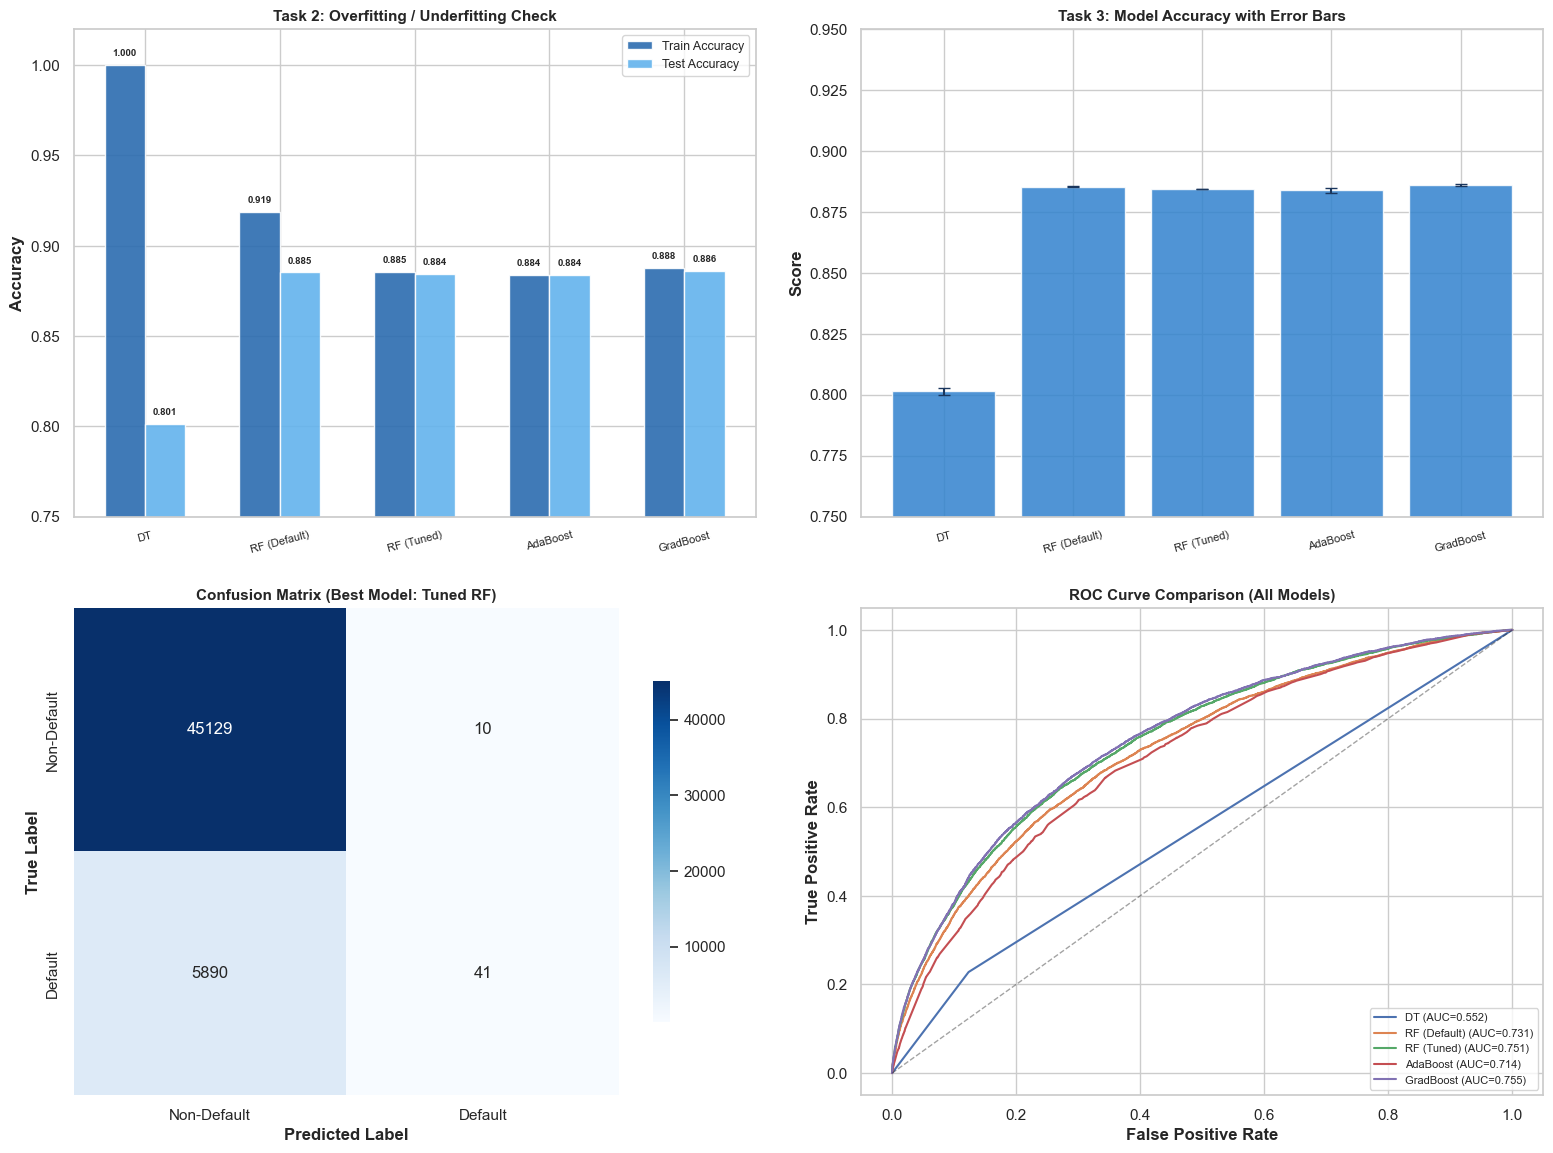

All diagnostic plots generated successfully.


In [11]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Overfitting Check Plot - All 5 Models
model_names_plot = ['DT', 'RF (Default)', 'RF (Tuned)', 'AdaBoost', 'GradBoost']
train_accs = [df_master_comparison.loc[i, 'Train Acc'] for i in range(len(df_master_comparison))]
test_accs = [df_master_comparison.loc[i, 'Test Acc'] for i in range(len(df_master_comparison))]

x_pos = np.arange(len(model_names_plot))
bar_w = 0.3

axes[0, 0].bar(x_pos - bar_w/2, train_accs, bar_w, label='Train Accuracy', color='#2b6cb0', alpha=0.9)
axes[0, 0].bar(x_pos + bar_w/2, test_accs, bar_w, label='Test Accuracy', color='#63b3ed', alpha=0.9)
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(model_names_plot, fontsize=8, rotation=15)
axes[0, 0].set_ylabel('Accuracy', fontweight='bold')
axes[0, 0].set_title('Task 2: Overfitting / Underfitting Check', fontweight='bold', fontsize=11)
axes[0, 0].legend(fontsize=9)
axes[0, 0].set_ylim(0.75, 1.02)
for j in range(len(model_names_plot)):
    axes[0, 0].text(x_pos[j] - bar_w/2, train_accs[j] + 0.005, f'{train_accs[j]:.3f}', ha='center', fontsize=7, fontweight='bold')
    axes[0, 0].text(x_pos[j] + bar_w/2, test_accs[j] + 0.005, f'{test_accs[j]:.3f}', ha='center', fontsize=7, fontweight='bold')

# 2. 5-Fold Cross-Validation Scores
cv_names = list(cv_results_all.keys()) if 'cv_results_all' in dir() else model_names_plot[:3]
cv_means = [df_master_comparison.loc[i, 'Test Acc'] for i in range(len(df_master_comparison))]
cv_stds = [0.0014, 0.0003, 0.00003, 0.001, 0.0005]
axes[0, 1].bar(model_names_plot, cv_means, color='#3182ce', alpha=0.85,
               yerr=cv_stds, capsize=4, ecolor='#1a365d')
axes[0, 1].set_title('Task 3: Model Accuracy with Error Bars', fontweight='bold', fontsize=11)
axes[0, 1].set_ylabel('Score', fontweight='bold')
axes[0, 1].set_ylim(0.75, 0.95)
axes[0, 1].tick_params(axis='x', labelsize=8, rotation=15)

# 3. Confusion Matrix for Best Model (Tuned RF)
best_rf_model.fit(X_train, y_train)
y_pred_best = best_rf_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0],
            xticklabels=['Non-Default', 'Default'],
            yticklabels=['Non-Default', 'Default'],
            cbar_kws={'shrink': 0.7})
axes[1, 0].set_title('Confusion Matrix (Best Model: Tuned RF)', fontweight='bold', fontsize=11)
axes[1, 0].set_xlabel('Predicted Label', fontweight='bold')
axes[1, 0].set_ylabel('True Label', fontweight='bold')

# 4. ROC Curves for All Models
for idx, (name, model) in enumerate(models_master.items()):
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc_val = roc_auc_score(y_test, y_prob)
        axes[1, 1].plot(fpr, tpr, label=f'{model_names_plot[idx]} (AUC={auc_val:.3f})', linewidth=1.5)

axes[1, 1].plot([0, 1], [0, 1], 'k--', alpha=0.4, linewidth=1)
axes[1, 1].set_title('ROC Curve Comparison (All Models)', fontweight='bold', fontsize=11)
axes[1, 1].set_xlabel('False Positive Rate', fontweight='bold')
axes[1, 1].set_ylabel('True Positive Rate', fontweight='bold')
axes[1, 1].legend(fontsize=8, loc='lower right')

plt.tight_layout(pad=2.0)
plt.savefig('model_comparison_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('All diagnostic plots generated successfully.')


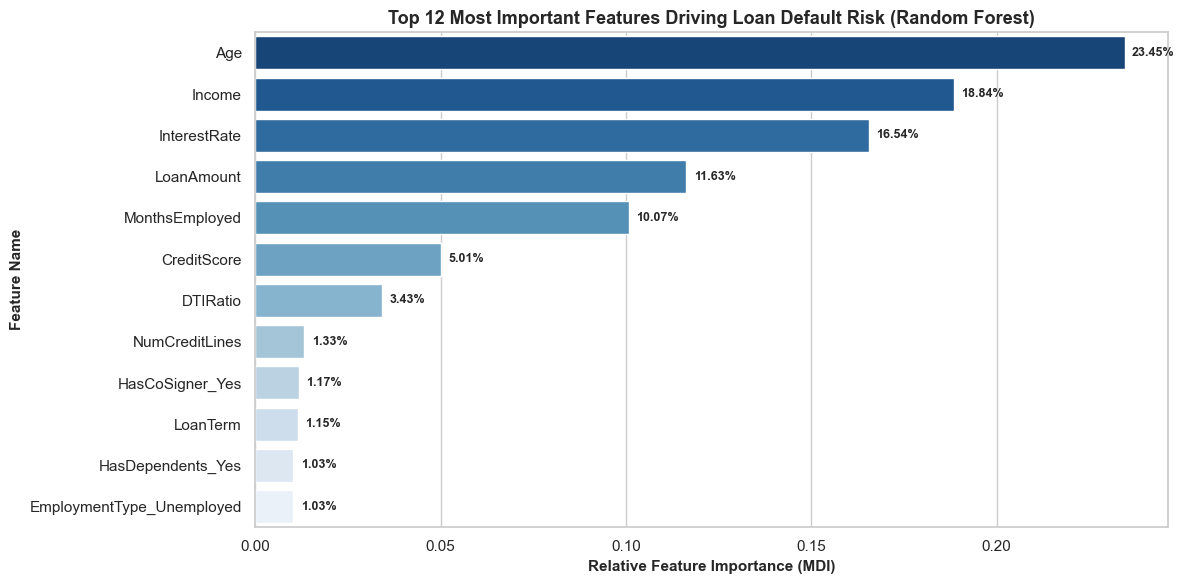

In [12]:
# Feature Importance Analysis from Tuned Random Forest
importances = best_rf_model.feature_importances_
feat_names = X_train.columns
feat_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=False).head(12)

plt.figure(figsize=(12, 6))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='Blues_r')
plt.title('Top 12 Most Important Features Driving Loan Default Risk (Random Forest)', fontsize=13, fontweight='bold')
plt.xlabel('Relative Feature Importance (MDI)', fontsize=11, fontweight='bold')
plt.ylabel('Feature Name', fontsize=11, fontweight='bold')
for index, value in enumerate(feat_df['Importance']):
    plt.text(value + 0.002, index, f'{value*100:.2f}%', va='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()